In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [165]:
df = pd.read_csv("data.csv")
pd.set_option('display.max_columns', None)
# pd.reset_option('display.max_columns')
# Маржа = цена продажи - себестоимость

df = df.drop_duplicates()

df["margin"] = df["sale_price"] - df["cost"]
df["revenue"] = df["sale_price"]

df['return_flg'] = (~df['returned_at'].isna()).astype(int)
df_delivered = df[df['status'].str.strip().str.lower() == 'complete']
df_delivered_not_returned = df[(df['status'].str.strip().str.lower() == 'complete') & (df['returned_at'].isna())]
df_returned = df[~(df['returned_at'].isna())]

total_revenue = df_delivered_not_returned["revenue"].sum()
total_margin = df_delivered_not_returned["margin"].sum()


исключаем дубликаты 

фильтры:
- status = Complete

retail_price — розничная цена до применения скидок

sale_proce — цена продажи

cost — себестоимость


# тут черновик с осмотром данных

In [230]:
df_delivered.head()

,order_id,user_id,status,gender,created_at,returned_at,shipped_at,delivered_at,num_of_item,product_id,inventory_item_id,sale_price,id,first_name,last_name,email,age,state,street_address,postal_code,city,country,traffic_source,user_geom,cost,category,brand,retail_price,department,sku,distribution_center_id,sold_at,product_category,product_name,product_brand,product_retail_price,product_department,product_sku,product_distribution_center_id,distribution_center_geom,order_item_id,delivery_longitude,delivery_latitude,warehouse_name,warehouse_longitude,warehouse_latitude,is_loyal,product_name_clean,customer_review,margin,revenue,date
3,99949,79993,Complete,F,2026-03-11 00:39:44.268552+00:00,NaN,2026-03-13 17:24:44.268552+00:00,2026-03-16 01:00:44.268552+00:00,1,15500,393298,25.000000,79993,Michelle,Alvarez,michellealvarez@example.net,26,Beijing,20341 Terri Crest,100023,Tieling,China,Search,POINT(116.5019973 39.83631574),13.750000,Plus,HUE,25.000000,Women,DF46E19EFFFE9C4CD3E8808359AA8C8A,2,NaN,Plus,HUE Women's 3-Pack Hidden Cotton Liner,HUE,25.000000,Women,DF46E19EFFFE9C4CD3E8808359AA8C8A,2,POINT(-87.6847 41.8369),145310,116.501997,39.836316,Chicago IL,-87.6847,41.8369,False,HUE Women's 3-Pack Hidden Cotton Liner,Nice HUE Women's 3-Pack Hidden Cotton Liner. W...,11.250000,25.000000,2026-03-11
15,68445,54695,Complete,F,2026-03-11 00:26:31.209017+00:00,NaN,2026-03-11 14:54:31.209017+00:00,2026-03-12 14:31:31.209017+00:00,2,7745,270356,51.990002,54695,Angela,Warner,angelawarner@example.net,45,Colorado,5783 Welch Via,80910,Colorado Springs,United States,Search,POINT(-104.772591 38.81029522),19.392271,Blazers & Jackets,Vobaga,51.990002,Women,58EC72DF0CACA51DF569D0B497C33805,2,NaN,Blazers & Jackets,Vobaga New Woman Girl Fashion Trendy Bling Bli...,Vobaga,51.990002,Women,58EC72DF0CACA51DF569D0B497C33805,2,POINT(-87.6847 41.8369),99783,-104.772591,38.810295,Chicago IL,-87.6847,41.8369,True,Vobaga New Woman Girl Fashion Trendy Bling Bli...,Another 5-star purchase! This Vobaga New Woman...,32.597731,51.990002,2026-03-11
16,68445,54695,Complete,F,2026-03-11 00:26:31.209017+00:00,NaN,2026-03-11 14:54:31.209017+00:00,2026-03-12 14:31:31.209017+00:00,2,7253,270352,88.000000,54695,Angela,Warner,angelawarner@example.net,45,Colorado,5783 Welch Via,80910,Colorado Springs,United States,Search,POINT(-104.772591 38.81029522),38.016000,Skirts,Democracy,88.000000,Women,7900770ABF7086FAAFD8C122981CC82F,2,NaN,Skirts,Democracy Women's Full Length Skirt,Democracy,88.000000,Women,7900770ABF7086FAAFD8C122981CC82F,2,POINT(-87.6847 41.8369),99782,-104.772591,38.810295,Chicago IL,-87.6847,41.8369,True,Democracy Women's Full Length Skirt,Another 5-star purchase! This Democracy Women'...,49.984000,88.000000,2026-03-11
17,58571,46784,Complete,F,2026-03-11 00:26:16.651687+00:00,NaN,2026-03-13 00:07:16.651687+00:00,2026-03-13 06:31:16.651687+00:00,2,14435,231012,29.980000,46784,Sheila,Rodriguez,sheilarodriguez@example.com,55,North Carolina,1099 Jason Field Suite 179,28560,New Bern,United States,Organic,POINT(-76.9760078 35.1190909),13.850760,Maternity,Motherhood Maternity,29.980000,Women,D169E16DA608A6A8D61BC64A2D333E8A,3,NaN,Maternity,Motherhood Maternity: Petite Secret Fit Belly(...,Motherhood Maternity,29.980000,Women,D169E16DA608A6A8D61BC64A2D333E8A,3,POINT(-95.3698 29.7604),85233,-76.976008,35.119091,Houston TX,-95.3698,29.7604,False,Motherhood Maternity: Petite Secret Fit Belly(...,Just received the Motherhood Maternity: Petite...,16.129240,29.980000,2026-03-11
18,58571,46784,Complete,F,2026-03-11 00:26:16.651687+00:00,NaN,2026-03-13 00:07:16.651687+00:00,2026-03-13 06:31:16.651687+00:00,2,9767,231010,68.000000,46784,Sheila,Rodriguez,sheilarodriguez@example.com,55,North Carolina,1099 Jason Field Suite 179,28560,New Bern,United States,Organic,POINT(-76.9760078 35.1190909),40.052000,Sleep & Lounge,Gaiam,68.000000,Women,E720A515B9DA87288D569CAA68F42BC1,5,NaN,Sleep & Lounge,White Organic Cotton Nightgown,Gaiam,68.000000,Women,E720A515B9DA87288D569CAA68F42BC1,5,POINT(-

In [103]:
df[(df['retail_price'] != df['product_retail_price']) | (df['retail_price'] != df['product_retail_price']).isna()]

,order_id,user_id,status,gender,created_at,returned_at,shipped_at,delivered_at,num_of_item,product_id,inventory_item_id,sale_price,id,first_name,last_name,email,age,state,street_address,postal_code,city,country,traffic_source,user_geom,cost,category,brand,retail_price,department,sku,distribution_center_id,sold_at,product_category,product_name,product_brand,product_retail_price,product_department,product_sku,product_distribution_center_id,distribution_center_geom,order_item_id,delivery_longitude,delivery_latitude,warehouse_name,warehouse_longitude,warehouse_latitude,is_loyal,product_name_clean,customer_review,margin,revenue,date


In [104]:
df[(df['sale_price'] != df['product_retail_price']) | (df['sale_price'] != df['product_retail_price']).isna()]

,order_id,user_id,status,gender,created_at,returned_at,shipped_at,delivered_at,num_of_item,product_id,inventory_item_id,sale_price,id,first_name,last_name,email,age,state,street_address,postal_code,city,country,traffic_source,user_geom,cost,category,brand,retail_price,department,sku,distribution_center_id,sold_at,product_category,product_name,product_brand,product_retail_price,product_department,product_sku,product_distribution_center_id,distribution_center_geom,order_item_id,delivery_longitude,delivery_latitude,warehouse_name,warehouse_longitude,warehouse_latitude,is_loyal,product_name_clean,customer_review,margin,revenue,date


то есть колонки эквивалентны

# топ продуктов

топ по сырым данным

In [231]:
n = 20
top_products = (
    df.groupby("product_name_clean")["margin"]
    .sum()
    .sort_values(ascending=False)
    .head(n)
)


print(top_products)

product_name_clean
The North Face Apex Bionic Soft Shell Jacket - Men's                         9873.401970
Darla                                                                        6538.454987
NIKE WOMEN'S PRO COMPRESSION SPORTS BRA *Outstanding Support and Comfort*    6329.127008
The North Face Freedom Mens Ski Pants 2013                                   5870.402982
The North Face Apex Bionic Mens Soft Shell Ski Jacket 2013                   5797.259981
The North Face Denali Down Womens Jacket 2013                                5250.041989
Canada Goose Men's The Chateau Jacket                                        5090.489985
Robert Graham Men's Barbican Velvet Blazer                                   4322.714008
The North Face Nuptse 2 Jacket Deep Water Blue Mens                          4283.831989
The North Face Women's S-XL Oso Jacket                                       4197.144002
Canada Goose Women's Solaris                                                 4195.019994
No

**топ продуктов без учета возвратов**

In [232]:
n = 20
top_products = (
    df_delivered.groupby("product_name_clean")["margin"]
    .sum()
    .sort_values(ascending=False)
    .head(n)
)


print(top_products)

product_name_clean
Darla                                                                        3566.429993
The North Face Denali Down Womens Jacket 2013                                3344.711993
Quiksilver Men's Rockefeller Walkshort                                       2153.655000
Canada Goose Women's Mystique                                                1732.499999
Nobis Yatesy Parka                                                           1704.299993
The North Face Freedom Mens Ski Pants 2013                                   1601.018995
The North Face Denali Down Mens Jacket 2013                                  1400.552992
Canada Goose Men's The Chateau Jacket                                        1392.019996
Catherine Malandrino Women's Skinny Stretch Leather Pant                     1382.775007
Harris Tweed Wool Jacket-Dougal Limited Edition                              1375.200002
Barbour Bedale Wax Cotton Jacket Olive                                       1364.399995
NI

**топ продуктов с исключением возвратов**

In [401]:
n = 20
top_products = (
    df_delivered_not_returned.groupby("product_name_clean")["margin"]
    .sum()
    .reset_index()
    .sort_values("margin", ascending=False)
    .head(n)
)


print(top_products)

                                      product_name_clean       margin
5941                                               Darla  3566.429993
18849      The North Face Denali Down Womens Jacket 2013  3344.711993
16154             Quiksilver Men's Rockefeller Walkshort  2153.655000
4288                       Canada Goose Women's Mystique  1732.499999
14461                                 Nobis Yatesy Parka  1704.299993
18851         The North Face Freedom Mens Ski Pants 2013  1601.018995
18848        The North Face Denali Down Mens Jacket 2013  1400.552992
4283               Canada Goose Men's The Chateau Jacket  1392.019996
4755   Catherine Malandrino Women's Skinny Stretch Le...  1382.775007
9244     Harris Tweed Wool Jacket-Dougal Limited Edition  1375.200002
2683              Barbour Bedale Wax Cotton Jacket Olive  1364.399995
13947  NIKE WOMEN'S PRO COMPRESSION SPORTS BRA *Outst...  1355.403004
19067  Tom Ford Marko FT0144 Sunglasses - 18V Shiny R...  1324.081206
2268                

In [402]:
n = 20
top_products = (
    df_delivered_not_returned.groupby("product_name_clean")["margin"]
    .sum()
    .reset_index()
    .sort_values("margin", ascending=True)
    .head(n)
)


print(top_products)

                                      product_name_clean   margin
10009         Indestructable Aluminum Aluma Wallet - RED  0.03510
17464  Set of 2 - Replacement Insert For Checkbook Wa...  0.31262
17996    Solid Color Leather Adjustable Skinny Belt with  0.86523
15550  Pink Ribbon Breast Cancer Awareness Knee High ...  1.03350
915    Alivila.Y Fashion Sexy Lace Lingerie Sleepwear...  1.05248
9758   Hyp Women's Short Sleeve Neptune Cotton Raglan...  1.26577
10018                           Individual Bra Extenders  1.47350
19328  TopTie Mens Black & White Checkerboard Pre-Tie...  1.51774
3176                          Black Terry 'Y' Suspenders  1.55120
20871  Women's Soft and Warm Striped Fuzzy Socks 12 C...  1.56350
2537                  BH Slipper Socks One Size Fits All  1.63800
6042   Designer Bow Ties for Men & Boys by Tok Tok De...  1.65200
945    Allegra K 5 Pcs Bra Black 2x3 Hooks Extenders ...  1.65467
8607                                 HDE Classic Bow Tie  1.66970
19862  Uni

**нет отрицательной маржи**

## по категориям

In [81]:
category_revenue = (
    df_delivered_not_returned.groupby("category")["revenue"]
    .sum()
    .reset_index()
    .sort_values("revenue", ascending=False)
    .head(15)
)

print(category_revenue)

                         category        revenue
11              Outerwear & Coats  334004.839748
7                           Jeans  310252.960490
22                       Sweaters  204246.170048
21            Suits & Sport Coats  166322.709674
5   Fashion Hoodies & Sweatshirts  163630.170081
23                           Swim  160743.130182
17                 Sleep & Lounge  137911.930437
15                         Shorts  134698.330380
24                    Tops & Tees  123476.890469
6                       Intimates  112151.570131
1                          Active  111403.160043
4                         Dresses  108725.120232
12                          Pants  105343.560343
0                     Accessories  105314.840000
2               Blazers & Jackets   77046.530220


In [82]:
category_margin = (
    df_delivered_not_returned.groupby("category")["margin"]
    .sum()
    .reset_index()
    .sort_values("margin", ascending=False)
    .head(15)
)

print(category_margin)

                         category         margin
11              Outerwear & Coats  185429.660208
7                           Jeans  143972.912990
22                       Sweaters  105656.127261
21            Suits & Sport Coats   99493.441222
5   Fashion Hoodies & Sweatshirts   78681.896905
23                           Swim   78524.266705
17                 Sleep & Lounge   72022.532448
15                         Shorts   67077.251818
1                          Active   64846.084539
0                     Accessories   63195.132289
4                         Dresses   59809.165314
12                          Pants   57104.121570
24                    Tops & Tees   54223.095362
6                       Intimates   52440.229654
2               Blazers & Jackets   47895.264931


In [171]:
def hist_plot(df, agg_col='category', target_col='revenue', top=13, relative=False, agg_func='sum', ylabel=None):
    plt.figure(figsize=(10, 7))

    if agg_func == 'sum':
        agg_df = (
            df.groupby(agg_col)[target_col]
            .sum()
            .reset_index()
            .sort_values(target_col, ascending=False)
            .head(top)
        )
        total = df[target_col].sum()

    elif agg_func == 'mean':
        agg_df = (
            df.groupby(agg_col)[target_col]
            .mean()
            .reset_index()
            .sort_values(target_col, ascending=False)
            .head(top)
        )
        total = 1

    elif agg_func == 'count':
        agg_df = (
            df.groupby(agg_col)[target_col]
            .count()
            .reset_index()
            .sort_values(target_col, ascending=False)
            .head(top)
        )
        total = df[target_col].count()
        
    part = agg_df[target_col].sum() / total
    print(part)
    
    if relative:
        agg_df[target_col] = agg_df[target_col] / total
    print(f"df.shape: {df.shape}")
    print(f"df['category'].value_counts(dropna=False).head()")
    print(f"df['return_flg'].dtype: {df['return_flg'].dtype}")
    print(f"agg_df: {agg_df}")
    if agg_df.empty:
        print("❌ agg_df пустой — проверьте данные!")
        return
    plt.bar(agg_df[agg_col], agg_df[target_col])
    plt.title((ylabel or target_col) + " by " + agg_col + f". part of total: {part:.2%}")
    plt.xlabel(agg_col)
    plt.ylabel(ylabel or target_col)

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()



0.8028037929875592


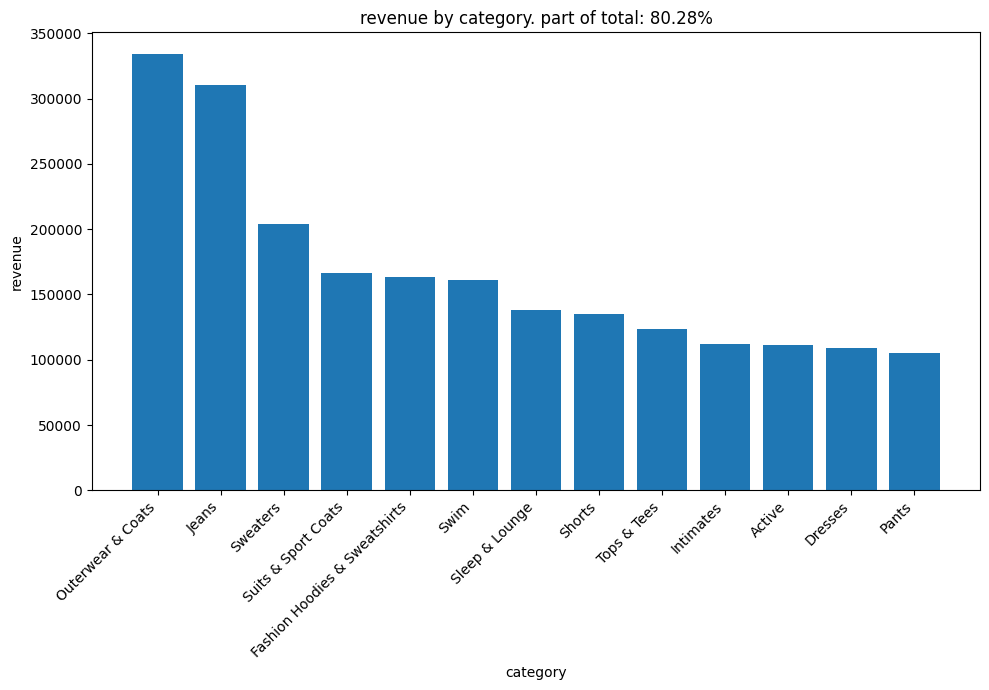

In [142]:
hist_plot(df_delivered_not_returned, agg_col='category', target_col='revenue', top=13, relative=False)

0.8045304422741202


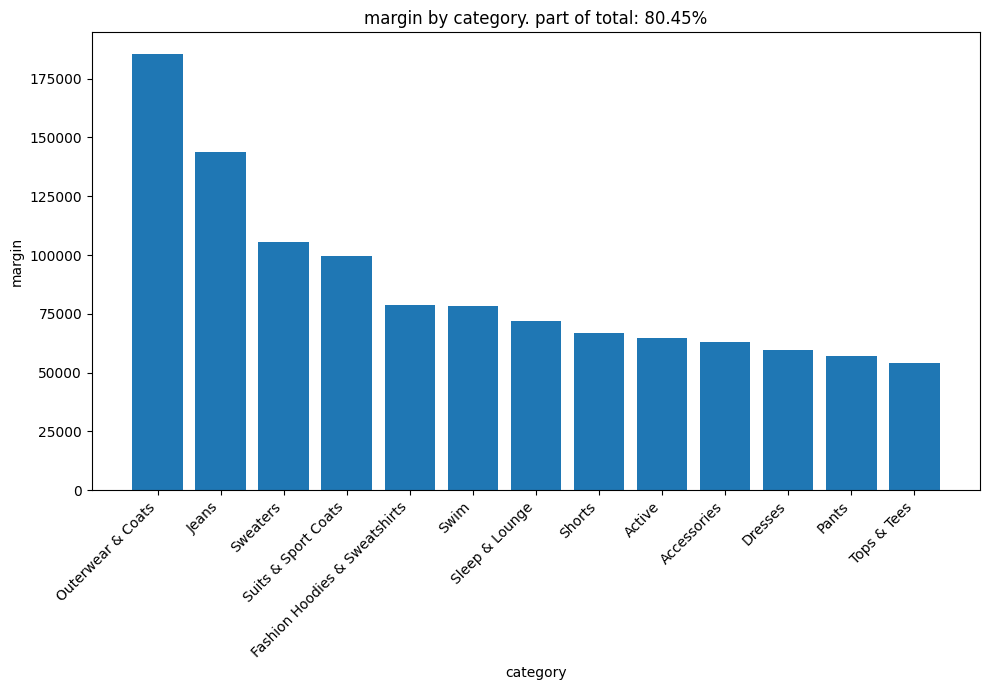

In [96]:
hist_plot(df_delivered_not_returned, agg_col='category', target_col='margin', top=13, relative=False)

1.346886568115563
df.shape: (181926, 52)
df['category'].value_counts(dropna=False).head()
df['return_flg'].dtype: int64
agg_df:                          category  return_flg
8             Jumpsuits & Rompers    0.113910
13                 Pants & Capris    0.110121
19                Socks & Hosiery    0.106507
21            Suits & Sport Coats    0.105000
23                           Swim    0.104446
17                 Sleep & Lounge    0.103663
25                      Underwear    0.103254
2               Blazers & Jackets    0.101705
18                          Socks    0.100981
14                           Plus    0.100817
24                    Tops & Tees    0.099549
5   Fashion Hoodies & Sweatshirts    0.098665
4                         Dresses    0.098267


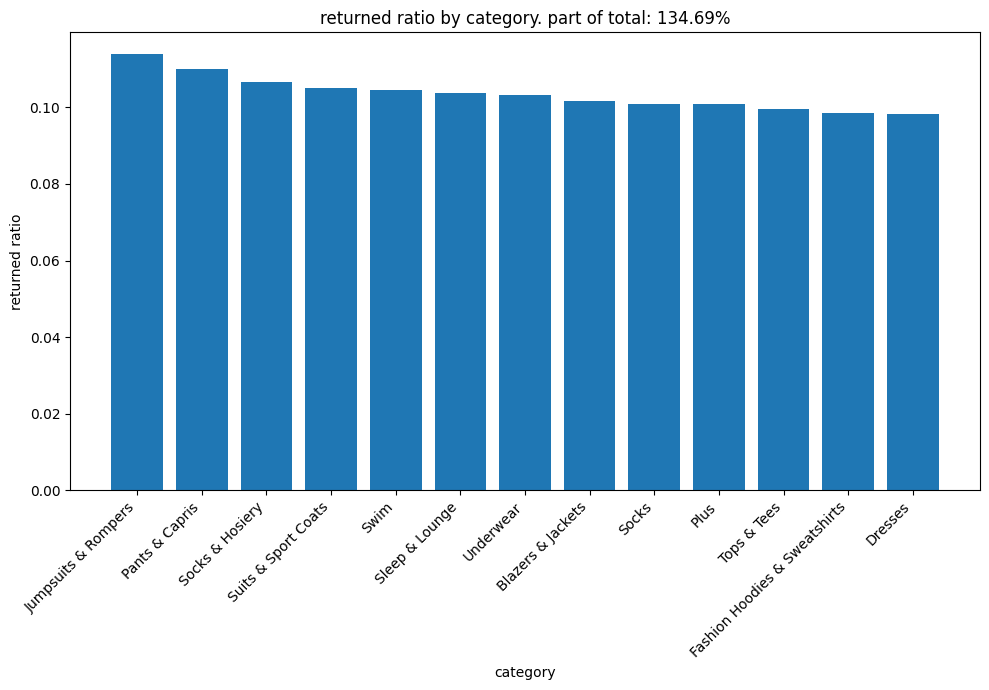

In [178]:
hist_plot(df, agg_col='category', target_col='return_flg', top=13, relative=False, agg_func='mean', ylabel='returned ratio')

0.7549264073085156


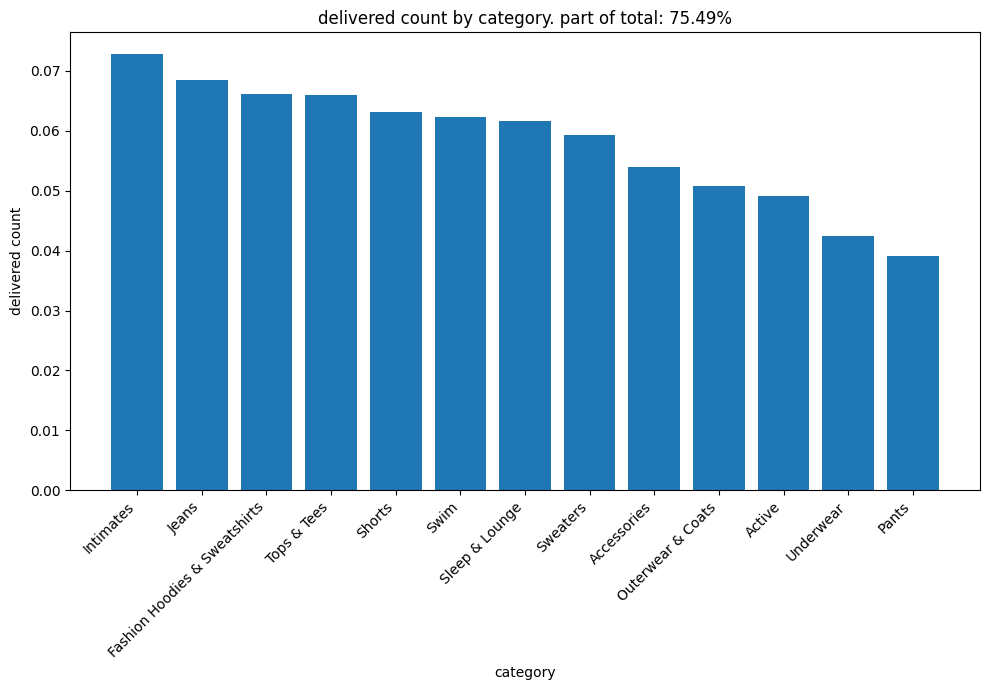

In [ ]:
hist_plot(df_delivered_not_returned, agg_col='category', target_col='revenue', top=13, relative=True, agg_func='count', ylabel='delivered count')

In [4]:
def get_top(df, agg_col="category", key_col='revenue', top=10, asc=False):
    return (
        df.groupby(agg_col)[key_col]
        .sum()
        .reset_index()
        .sort_values(key_col, ascending=asc)
        .head(top)
    )


def group_periodly(df, agg_col='category', datetime_col='created_at', period='D', target_col='revenue', asc=False):
    df_ = df.copy()

    df_['date'] = pd.to_datetime(df[datetime_col], errors='coerce', format='ISO8601')
    df_['date'] = df_['date'].dt.to_period(period)
    df_['date'] = df_['date'].dt.to_timestamp()
    df_['date'] = df_['date'].dt.tz_localize(None)

    categorized_data = (
        df_.groupby([agg_col, 'date'])[target_col]
        .sum()
        .reset_index()
        .sort_values(target_col, ascending=asc)
    )

    return categorized_data

In [331]:
group_periodly(df)

/var/folders/8g/d6r46rhj34b41z5lxp_7zfr00000gp/T/ipykernel_22474/2903395588.py:15: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_['date'] = df_['date'].dt.to_period(period)


,category,date,revenue
13889,Jeans,2026-03-10,19308.550028
19669,Outerwear & Coats,2026-03-10,17296.829979
37852,Sweaters,2026-03-10,14743.239985
19667,Outerwear & Coats,2026-03-08,10422.929977
19668,Outerwear & Coats,2026-03-09,10407.800022
...,...,...,...
32164,Socks & Hosiery,2022-06-27,1.950000
31809,Socks & Hosiery,2020-04-01,1.950000
258,Accessories,2020-11-23,1.820000
394,Accessories,2021-06-05,1.510000


Outerwear & Coats
Jeans
Sweaters
Suits & Sport Coats
Fashion Hoodies & Sweatshirts


/var/folders/8g/d6r46rhj34b41z5lxp_7zfr00000gp/T/ipykernel_28809/1177473649.py:15: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_['date'] = df_['date'].dt.to_period(period)


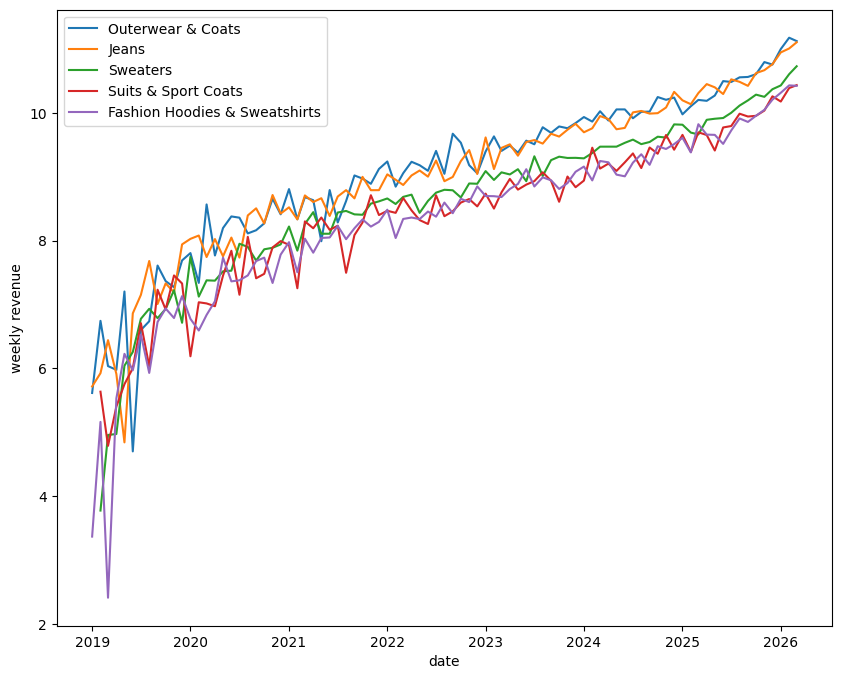

In [15]:
plt.figure(figsize=(10, 8))

categorized_data = group_periodly(df, agg_col='category', datetime_col='created_at', period='M', target_col='revenue')

top_categories = get_top(df, "category", "revenue", top=5)

for c in top_categories["category"]:
    print(c)
    category_data = categorized_data[categorized_data['category'] == c]
    category_data = category_data.sort_values('date')
    plt.plot(category_data['date'], np.log(category_data['revenue']), label=c)

plt.xlabel('date')
plt.ylabel('weekly revenue')
plt.legend()


## прогноз

In [116]:
from prophet import Prophet

def get_forecast(df, agg_col='category', target_col='revenue', period='D', top=5, plot=True, plot_components=True, logscale=True):
    top = get_top(df, agg_col, target_col, top=top)

    category = top[agg_col].iloc[0]
    categorized_data = group_periodly(df, agg_col=agg_col, datetime_col='created_at', period=period, target_col=target_col)
    data = categorized_data[categorized_data[agg_col] == category]
    data['value'] = np.log(data[target_col]) if logscale else data[target_col]
    prophet_df = data.reset_index().rename(columns={'date': 'ds', 'value': 'y'})

    model = Prophet(interval_width=0.99)
    model.fit(prophet_df)

    future = model.make_future_dataframe(periods=365, freq=period)

    forecast = model.predict(future)

    if plot_components:
        model.plot_components(forecast);
    
    if plot:
        model.plot(forecast);
        plt.title('forecast for ' + agg_col + ' ' + category + f'. logscale: {logscale}');
        plt.xlabel('date');
        plt.ylabel(target_col);

    return forecast, plt.gcf()


### выручка по категориям

/var/folders/8g/d6r46rhj34b41z5lxp_7zfr00000gp/T/ipykernel_28809/1177473649.py:15: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_['date'] = df_['date'].dt.to_period(period)
01:48:05 - cmdstanpy - INFO - Chain [1] start processing
01:48:05 - cmdstanpy - INFO - Chain [1] done processing


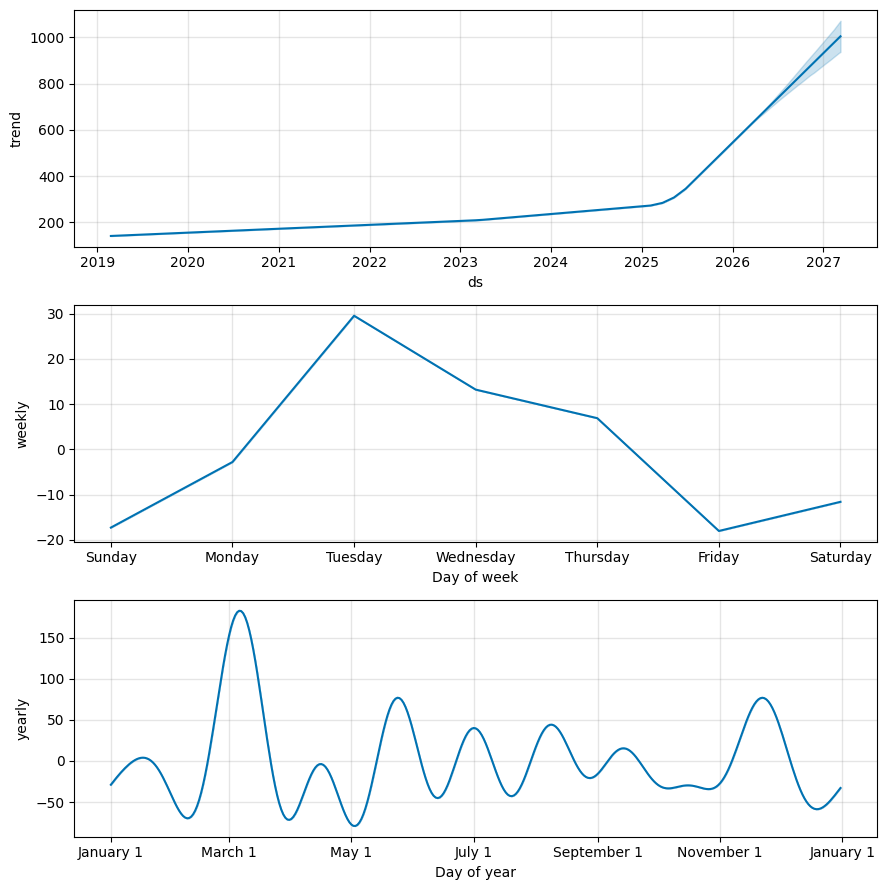

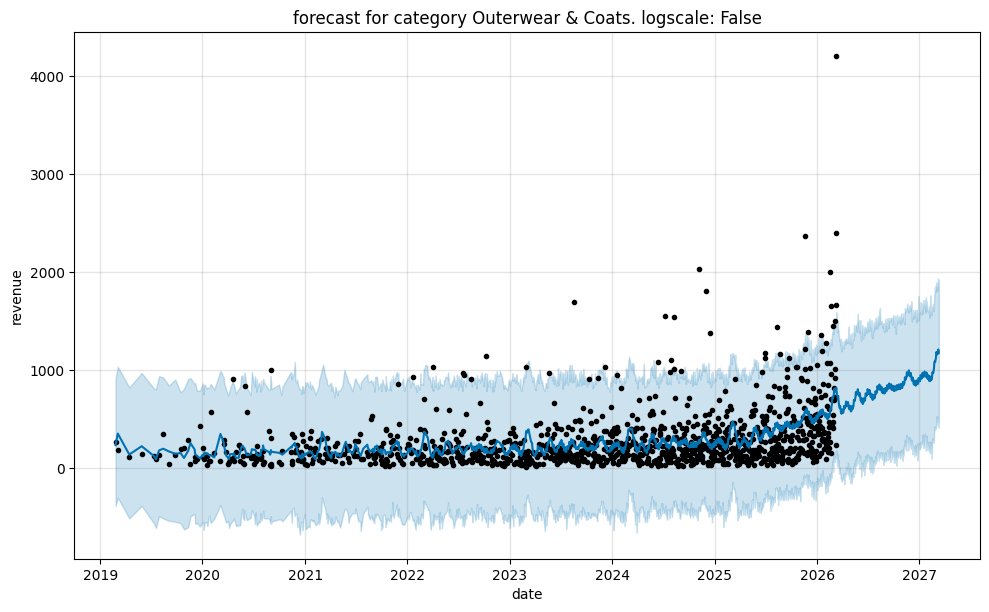

In [118]:
revenue_category_forecast_no_churn = get_forecast(df_delivered_not_returned, agg_col='category', target_col='revenue', period='D', top=5, plot=True, plot_components=True, logscale=False)

/var/folders/8g/d6r46rhj34b41z5lxp_7zfr00000gp/T/ipykernel_28809/1177473649.py:15: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_['date'] = df_['date'].dt.to_period(period)
01:42:12 - cmdstanpy - INFO - Chain [1] start processing
01:42:12 - cmdstanpy - INFO - Chain [1] done processing


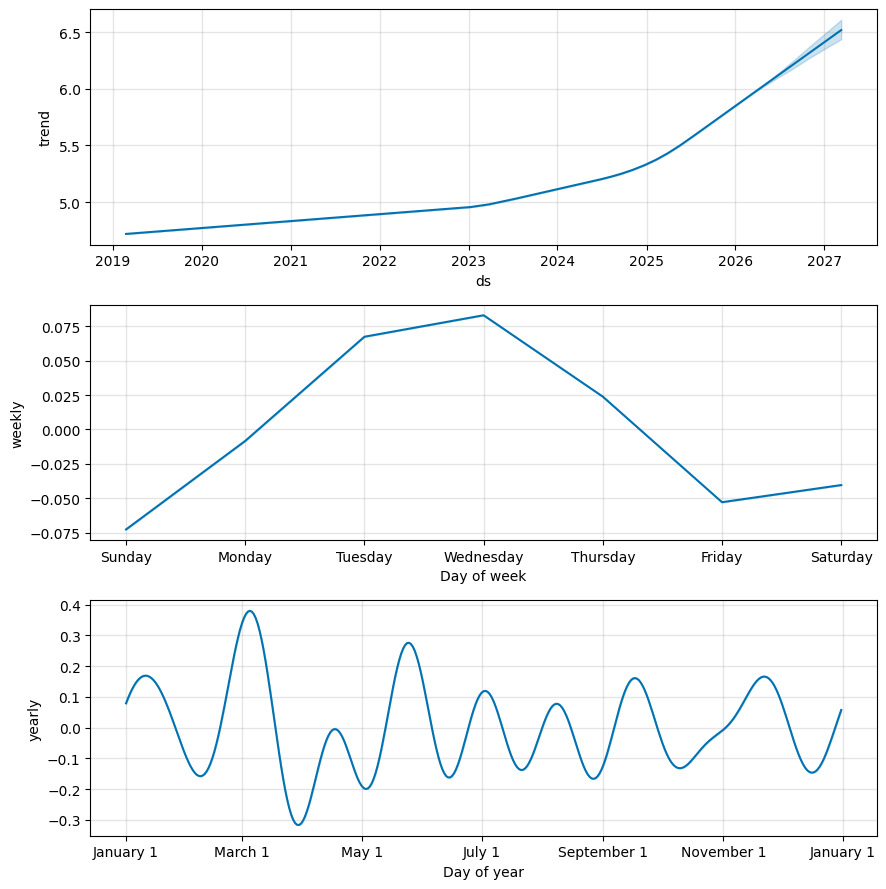

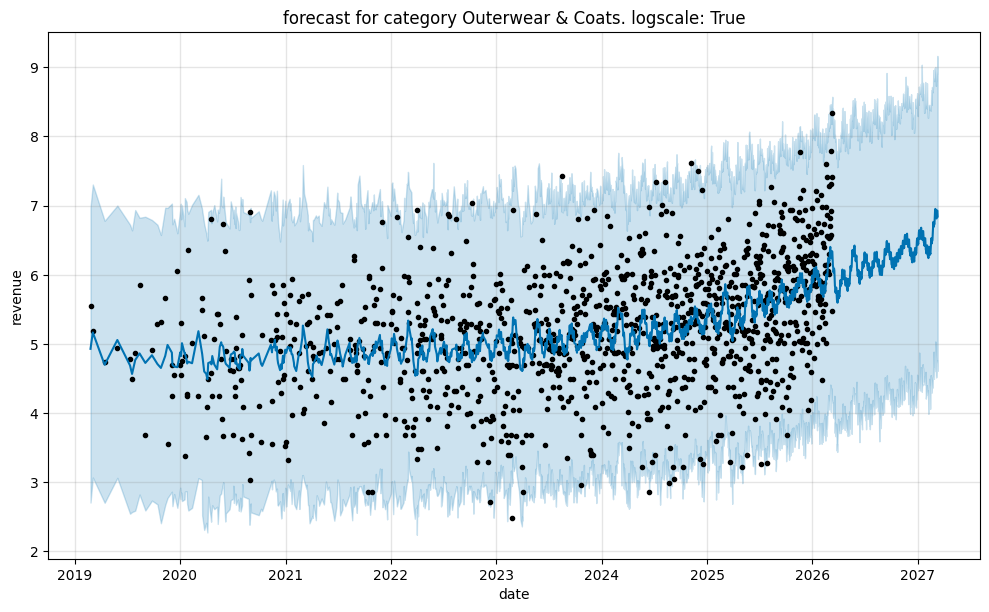

In [113]:
revenue_category_forecast_no_churn = get_forecast(df_delivered, agg_col='category', target_col='revenue', period='D', top=5, plot=True, plot_components=True)

### выручка по продуктам

/var/folders/8g/d6r46rhj34b41z5lxp_7zfr00000gp/T/ipykernel_28809/1177473649.py:15: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_['date'] = df_['date'].dt.to_period(period)


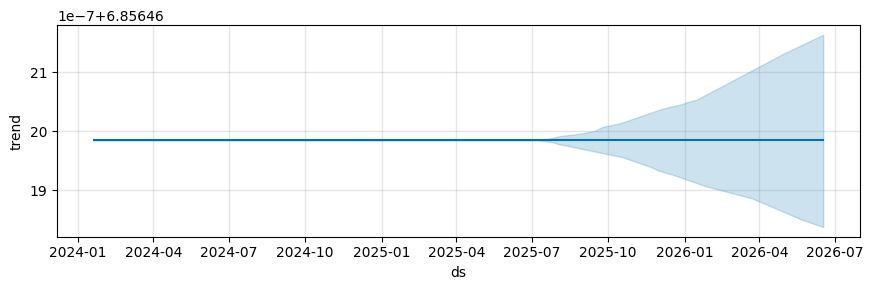

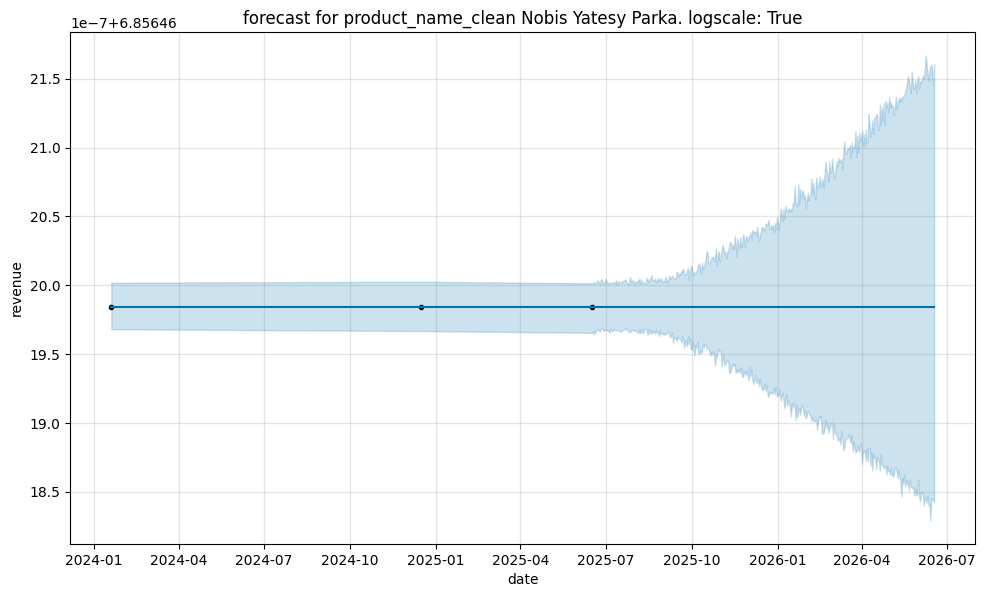

In [115]:
revenue_product_forecast_no_churn = get_forecast(df_delivered_not_returned, agg_col='product_name_clean', target_col='revenue', period='D', top=5, plot=True, plot_components=True, logscale=True)

/var/folders/8g/d6r46rhj34b41z5lxp_7zfr00000gp/T/ipykernel_28809/1177473649.py:15: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_['date'] = df_['date'].dt.to_period(period)


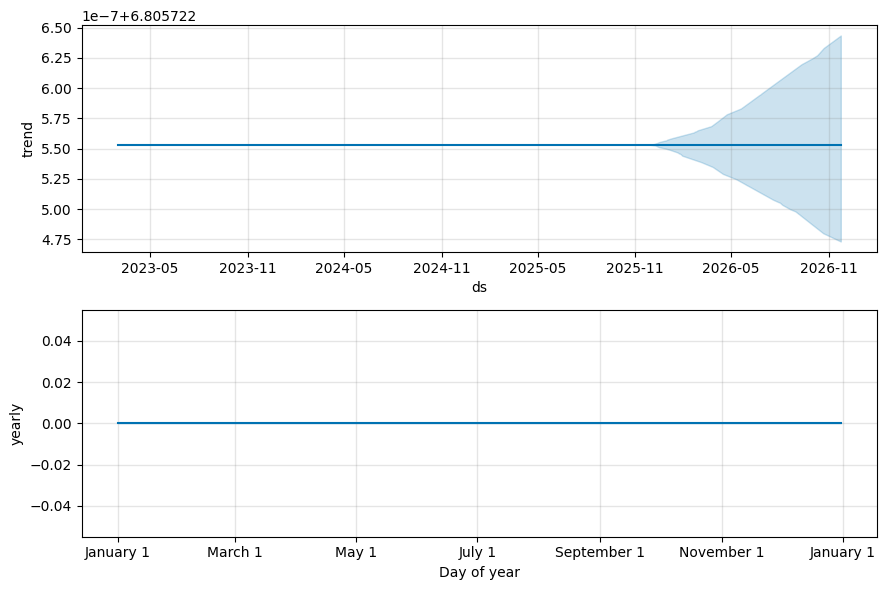

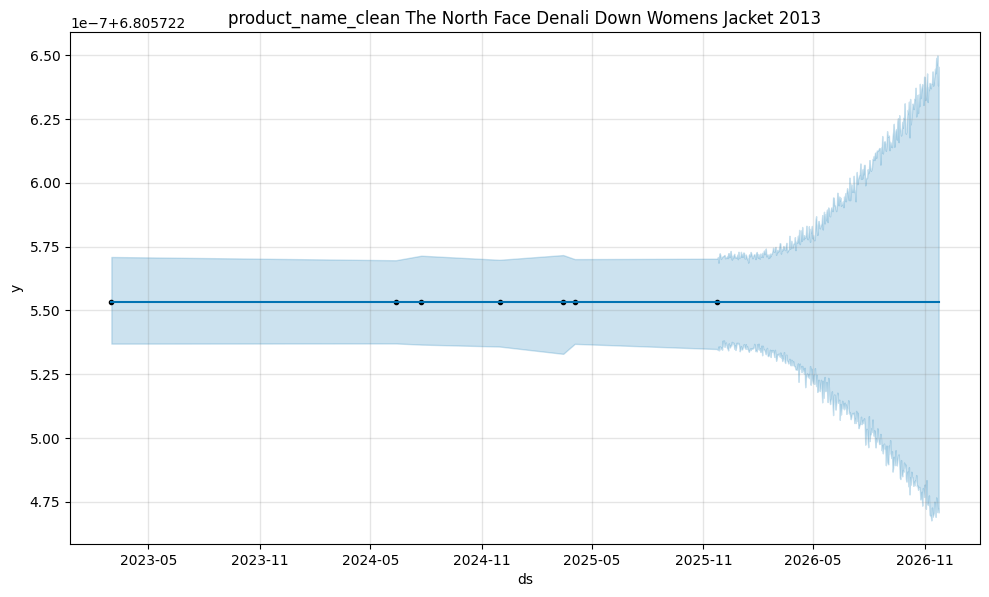

In [67]:
revenue_product_forecast = get_forecast(df_delivered, agg_col='product_name_clean', target_col='revenue', period='D', top=5, plot=True, plot_components=True, logscale=True)

### маржа по категорям

/var/folders/8g/d6r46rhj34b41z5lxp_7zfr00000gp/T/ipykernel_28809/1177473649.py:15: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_['date'] = df_['date'].dt.to_period(period)
01:47:10 - cmdstanpy - INFO - Chain [1] start processing
01:47:10 - cmdstanpy - INFO - Chain [1] done processing


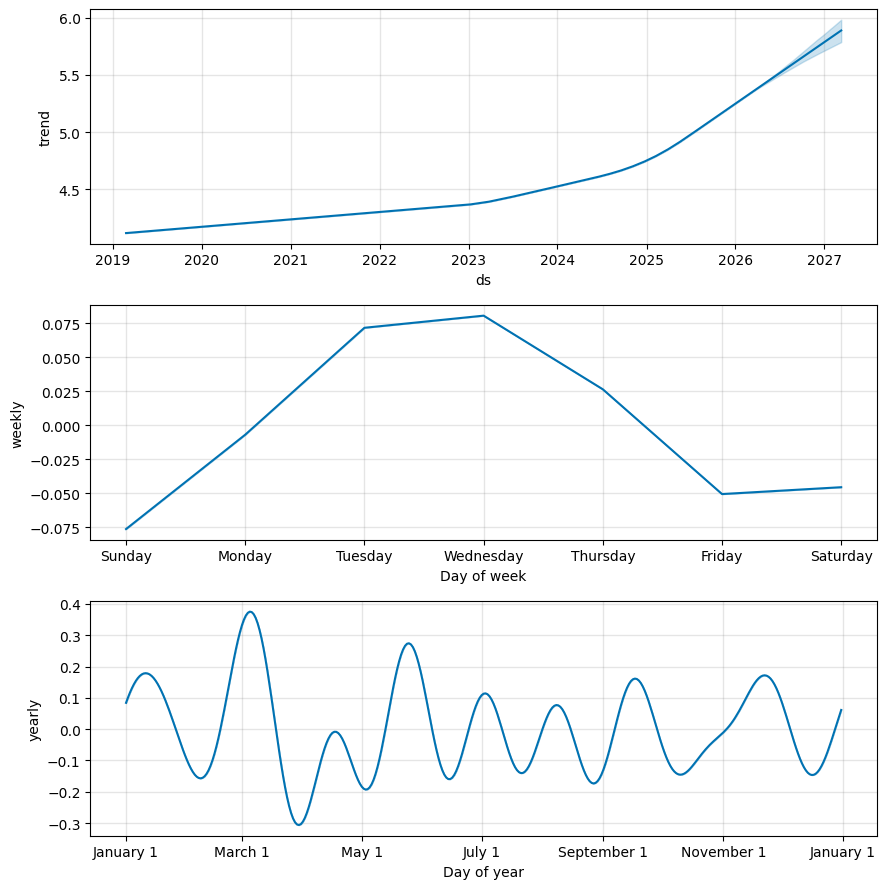

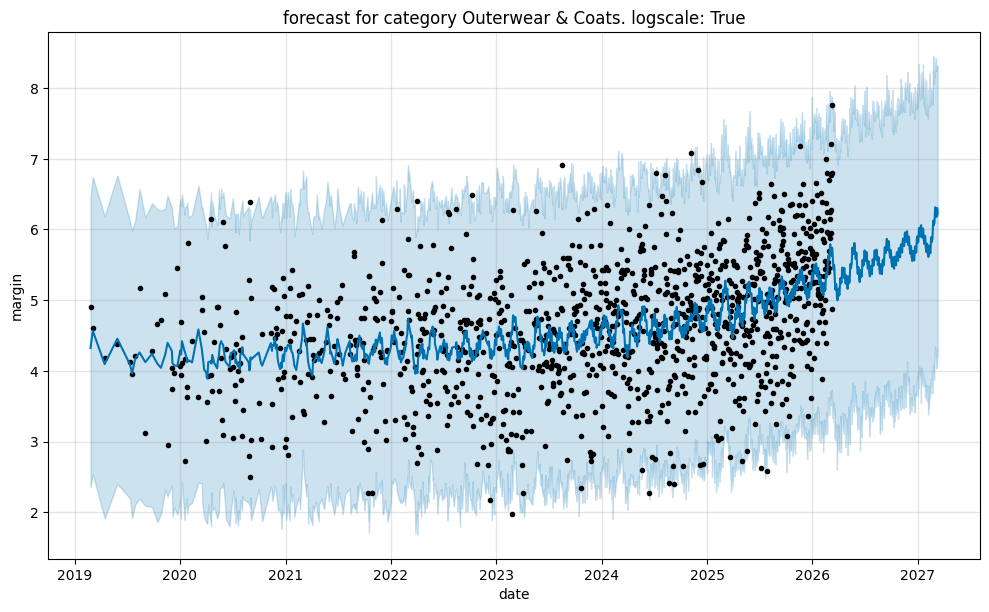

In [117]:
revenue_product_forecast_no_churn = get_forecast(df_delivered_not_returned, agg_col='category', target_col='margin', period='D', top=5, plot=True, plot_components=True, logscale=True)

### маржа по продуктам

/var/folders/8g/d6r46rhj34b41z5lxp_7zfr00000gp/T/ipykernel_28809/1177473649.py:15: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_['date'] = df_['date'].dt.to_period(period)


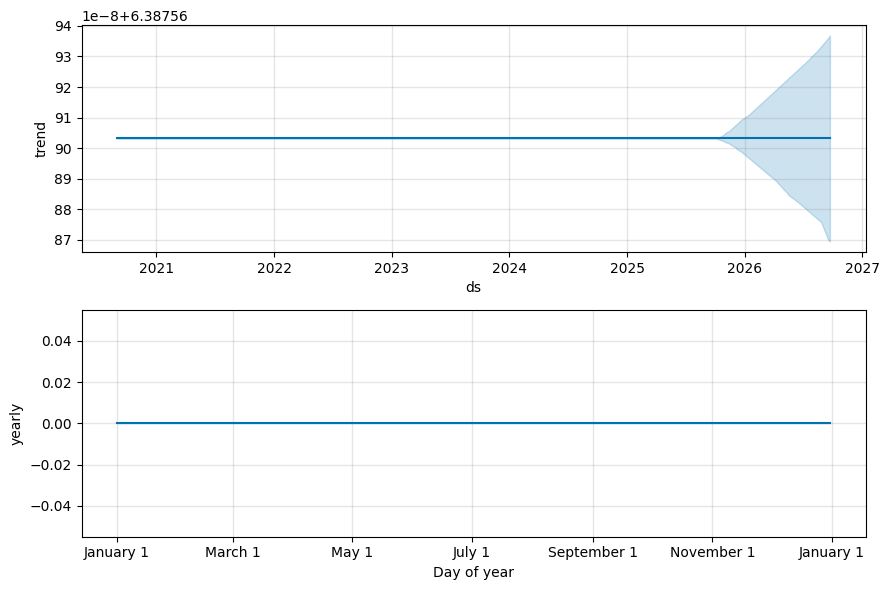

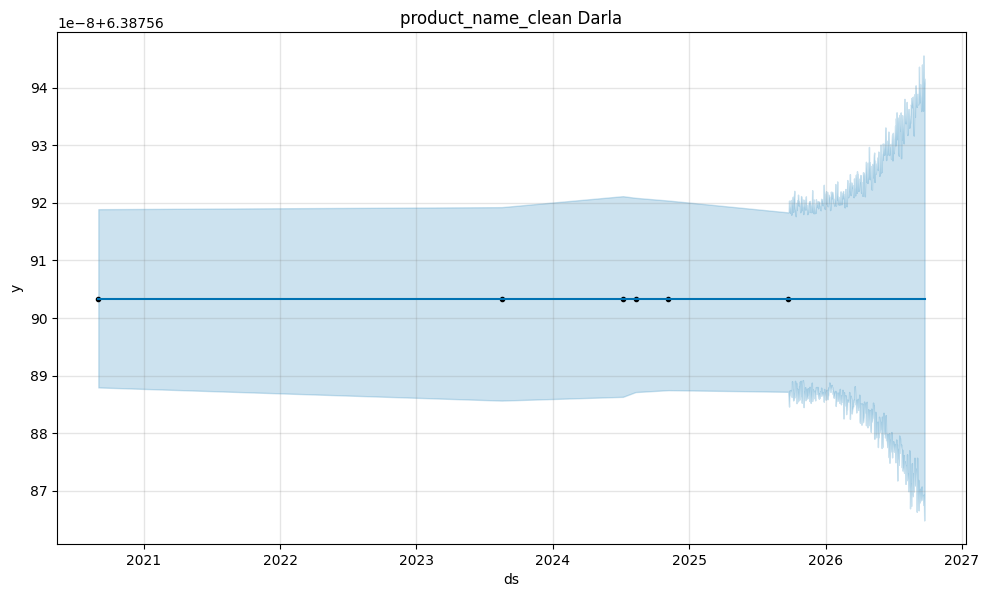

In [70]:
revenue_product_forecast = get_forecast(df_delivered, agg_col='product_name_clean', target_col='margin', period='D', top=5, plot=True, plot_components=True, logscale=True)